## Problem Statement:

The objective of this project is to predict an individual’s income using various demographic and socioeconomic features. Since the target variable (income) is continuous, this problem is formulated as a supervised learning regression task.

## 1. Data Collection 

Import the libraries what needed 

In [2]:
import pandas as pd

In [3]:
income = pd.read_csv("household income.csv")
income 

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,58,High School,Others,0,Suburban,26,Divorced,Full-time,6,Own,Townhouse,Female,Car,74994
9996,23,Master's,Technology,3,Urban,16,Divorced,Full-time,1,Own,Single-family home,Female,Biking,72676
9997,41,Doctorate,Education,3,Urban,50,Single,Full-time,4,Own,Single-family home,Female,Public transit,2684820
9998,44,High School,Education,0,Urban,3,Married,Part-time,1,Own,Single-family home,Male,Biking,57955


Assumptions: 

It is assumed that the dataset reflects realistic relationships between demographic factors and income, making it suitable for building regression models.

## 2. Dataset Shape

Observations: 
The dataset contains 10,000 records and 14 features. Each row represents an individual, and each column corresponds to a demographic or socioeconomic attribute related to that individual.

In [4]:
income.shape    

(10000, 14)

Assumptions

It is assumed that among the 14 features, some variables have a significant influence on the target variable (income). These relationships will be explored further during exploratory data analysis.

## 3. Dataset Preview

Observations

The target variable income contains no missing values, indicating that all records have valid income entries.

In [5]:
income.isnull().sum()


Age                               0
Education_Level                   0
Occupation                        0
Number_of_Dependents              0
Location                          0
Work_Experience                   0
Marital_Status                    0
Employment_Status                 0
Household_Size                    0
Homeownership_Status              0
Type_of_Housing                   0
Gender                            0
Primary_Mode_of_Transportation    0
Income                            0
dtype: int64

Assumptions

Since there are no missing values in the target variable, no imputation or data cleaning is required for income. This ensures that the model can be trained without loss of data due to missing target values.

# Observations

The target variable income contains no duplicate values (or negligible duplicates), indicating that each record has a unique income entry.

In [6]:
income.duplicated().sum()

np.int64(0)

Assumptions

Since there are no duplicate values in the target variable, it is assumed that there is no redundancy in the income data, and each value corresponds to a distinct observation.

# Observations

The dataset contains 10,000 entries and 14 columns, with all columns having 10000 non-null values, indicating that there are no missing values in the dataset.

The dataset consists of:

5 numerical features (int64)
9 categorical features (object)

The target variable Income is numerical (int64), making it suitable for regression tasks.

The features include a mix of demographic attributes (Age, Gender, Marital Status) and socioeconomic attributes (Education Level, Occupation, Work Experience, etc.).

In [7]:
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

Assumptions

Since the dataset contains multiple categorical variables, it is assumed that encoding techniques (such as One-Hot Encoding or Label Encoding) will be required before applying machine learning models.

The presence of both demographic and socioeconomic features suggests that income is likely influenced by multiple interacting factors, which may require feature engineering to capture relationships effectively.

As there are no missing values, it is assumed that no imputation is required, simplifying the preprocessing pipeline.

# Observations

The Income variable has:

Mean = 816,838
Median = 729,430
Standard Deviation = 1,821,089 (very high)

This clearly shows:

Mean > Median - right-skewed distribution

The range of income is very wide:

Min = 31,044
Max = 9,992,571

 Huge spread - indicates presence of extreme values (outliers)

Other numerical features:

Age ranges from 18 to 70 - realistic
Work Experience ranges from 0 to 50 - logical
Household Size ranges from 1 to 7 - consistent
Dependents ranges from 0 to 5 - reasonable

 These features look well-bounded and clean
 

In [8]:
income.describe()

,Age,Number_of_Dependents,Work_Experience,Household_Size,Income
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,44.021700,2.527000,24.858800,3.989600,8.168382e+05
std,15.203998,1.713991,14.652622,2.010496,1.821089e+06
min,18.000000,0.000000,0.000000,1.000000,3.104400e+04
25%,31.000000,1.000000,12.000000,2.000000,6.844600e+04
50%,44.000000,3.000000,25.000000,4.000000,7.294300e+04
75%,57.000000,4.000000,37.000000,6.000000,3.506675e+05
max,70.000000,5.000000,50.000000,7.000000,9.992571e+06


Assumptions

Since the income variable is highly skewed and has extreme values, it is assumed that outliers are present, which may negatively impact the performance of Linear Regression.

# Observations

The income variable contains a high number of unique values, indicating that income is a continuous variable with minimal repetition across records.

In [9]:
income.nunique()

Age                                 53
Education_Level                      4
Occupation                           5
Number_of_Dependents                 6
Location                             3
Work_Experience                     51
Marital_Status                       3
Employment_Status                    3
Household_Size                       7
Homeownership_Status                 2
Type_of_Housing                      3
Gender                               2
Primary_Mode_of_Transportation       4
Income                            7667
dtype: int64

Assumptions

Since income has many unique values, it is suitable for regression modeling, as it represents a continuous target variable rather than categorical or discrete classes.

The high uniqueness also suggests that the dataset likely does not suffer from excessive duplication in the target variable.

In [10]:
income.head()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210


In [11]:
income["Marital_Status"].value_counts()


Marital_Status
Married     5136
Single      3900
Divorced     964
Name: count, dtype: int64

In [12]:
income["Education_Level"].value_counts()

Education_Level
Bachelor's     4058
High School    2959
Master's       2482
Doctorate       501
Name: count, dtype: int64

In [13]:
income['Income'].value_counts(normalize=True) 

Income
74306     0.0010
71180     0.0007
72296     0.0006
68116     0.0006
74294     0.0006
           ...  
494819    0.0001
68096     0.0001
74146     0.0001
66602     0.0001
149465    0.0001
Name: proportion, Length: 7667, dtype: float64

Observations

The distribution of the income variable is highly right-skewed, with most values concentrated at the lower end and a long tail extending towards very high income values.

A large number of individuals fall within a low to mid income range, while very few individuals have extremely high income.

The presence of a long tail indicates extreme values (outliers) in the dataset.

/tmp/ipykernel_21584/2680361836.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Income', data=income, palette='viridis',kde=True)


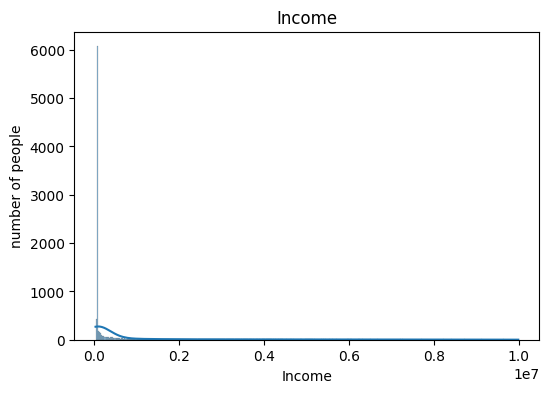

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.histplot(x='Income', data=income, palette='viridis',kde=True)

plt.title("Income")
plt.xlabel("Income")
plt.ylabel("number of people")

plt.show()

Assumptions

Since the income distribution is heavily skewed, it is assumed that outliers are influencing the distribution, which may negatively impact model performance.

Due to this skewness, applying a log transformation to the income variable may help in normalizing the distribution and improving the performance of regression models.

## Univariate Analysis

Observations

The dataset contains multiple numerical features including Age, Number of Dependents, Work Experience, Household Size, and Income.

These features represent quantitative attributes that can be directly used for statistical analysis and modeling.

In [20]:
num_cols = income.select_dtypes(include="number").columns.tolist()
num_cols

['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size', 'Income']

Assumptions

Since these variables are numerical, they can be used directly in regression models without encoding. However, scaling or transformation may be required depending on their distribution and variance.

Observations
Age
Age is fairly uniformly distributed between 18 and 70, with no extreme concentration in any specific range.

Work Experience
Work Experience also shows a relatively uniform distribution, indicating balanced representation across different experience levels.

Number of Dependents
This is a discrete feature with values from 0 to 5, showing distinct spikes at each value rather than a continuous distribution.

Household Size
Household Size is also discrete, ranging from 1 to 7, with fairly even distribution across categories.

Income 
Income is highly right-skewed, with most values concentrated at the lower end and a long tail extending toward higher values.

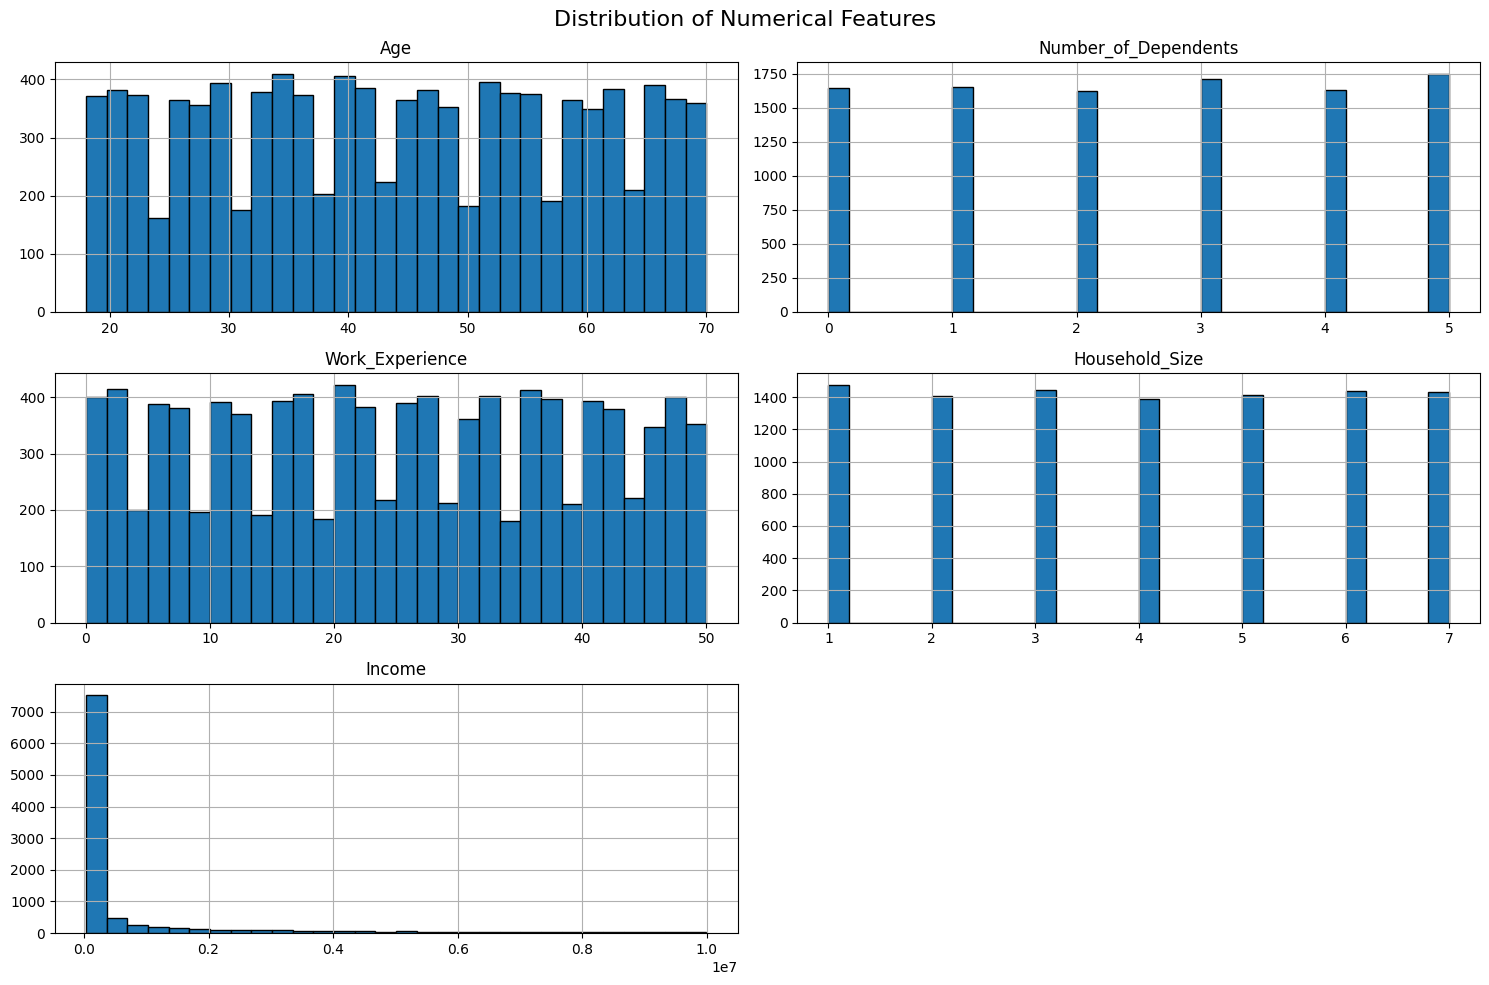

In [22]:
import matplotlib.pyplot as plt
income[num_cols].hist(figsize=(15,10), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Assumptions

Numerical features like Age and Work Experience appear to be well distributed and may contribute effectively to model learning.

Discrete features such as Number of Dependents and Household Size may behave more like categorical variables and might require special handling depending on the model.

The skewed nature of the Income variable suggests that transformation (e.g., log transformation) may be necessary to improve model performance.

## Outliers

Observations
Age
Age shows a fairly symmetric distribution with no significant outliers. Most values lie within a reasonable range (approx. 30–55).

Work Experience
Work Experience also appears well distributed with no major outliers, indicating consistent data.

Number of Dependents
This feature shows no extreme outliers and behaves like a bounded discrete variable.

Household Size
Household Size is also well-bounded with no visible outliers, indicating stable distribution.

Income 
The Income variable shows a large number of extreme outliers, with many points far beyond the upper whisker.

So this says:

heavy skewness
extreme high-income values

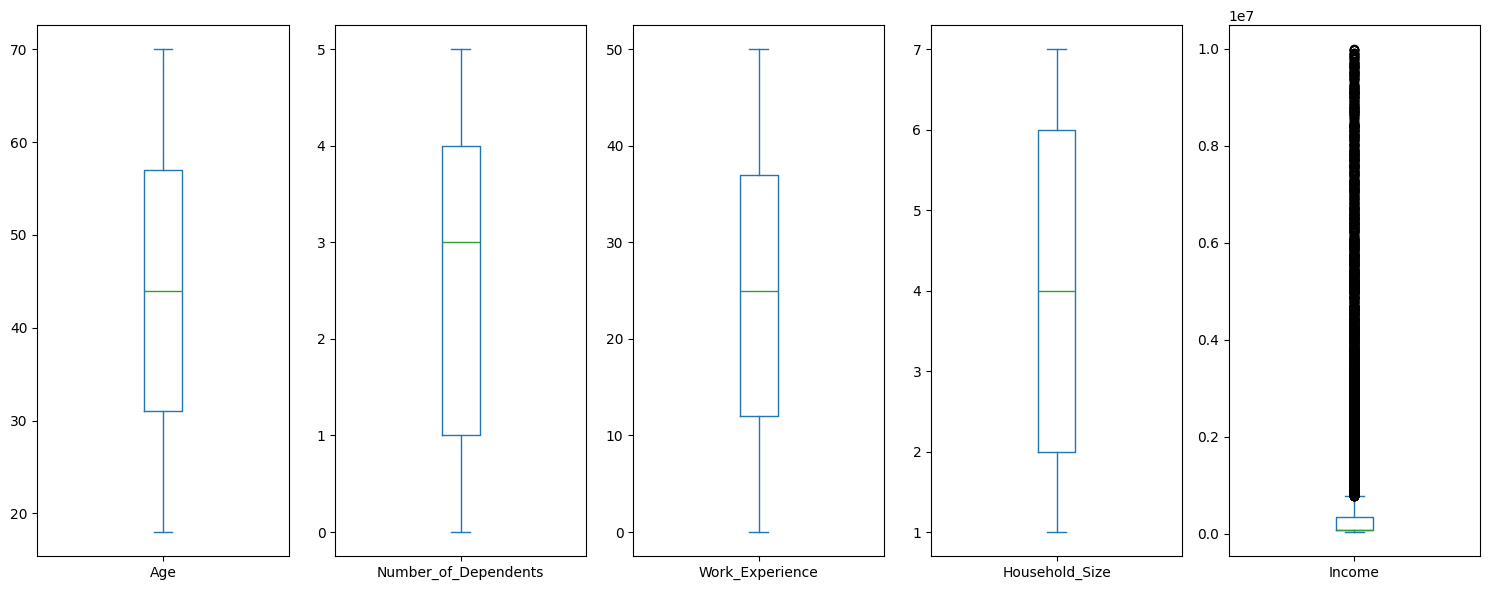

In [23]:
income[num_cols].plot(kind='box', subplots=True, figsize=(15, 6))  #box plot of detecting the outliers and the spread of the data 
plt.tight_layout()
plt.show()


Assumptions

Since most numerical features do not contain significant outliers, they are unlikely to negatively impact model performance.
But, the presence of extreme outliers in the income variable suggests that the target variable may require transformation or outlier handling to improve model stability.


## Categorical Values 

Observations

The dataset contains several categorical features stored as object data types, representing qualitative attributes such as education, occupation, location, and Other information.

In [24]:
cat_cols = income.select_dtypes(include=['object', 'string', 'category']).columns.tolist() # for categorical data 
cat_cols

['Education_Level',
 'Occupation',
 'Location',
 'Marital_Status',
 'Employment_Status',
 'Homeownership_Status',
 'Type_of_Housing',
 'Gender',
 'Primary_Mode_of_Transportation']

Assumptions

These categorical features will require encoding before being used in regression models, as machine learning algorithms cannot directly process non-numeric data.

------------------------------------------------------------------------------------

Observations 

Most categorical features have low cardinality (3–5 unique values)

Some features show imbalance, for example:

Urban location has significantly more samples than Rural
Bachelor’s degree is more common than Doctorate

In [26]:
for col in cat_cols:   #each categorical column will be analysed uniquely 
    print(f'--- {col} ---')
    print(income[col].value_counts())
    print(f'Unique values: {income[col].nunique()}')
    print()

--- Education_Level ---
Education_Level
Bachelor's     4058
High School    2959
Master's       2482
Doctorate       501
Name: count, dtype: int64
Unique values: 4

--- Occupation ---
Occupation
Healthcare    3035
Technology    2407
Finance       1525
Others        1521
Education     1512
Name: count, dtype: int64
Unique values: 5

--- Location ---
Location
Urban       7037
Suburban    1951
Rural       1012
Name: count, dtype: int64
Unique values: 3

--- Marital_Status ---
Marital_Status
Married     5136
Single      3900
Divorced     964
Name: count, dtype: int64
Unique values: 3

--- Employment_Status ---
Employment_Status
Full-time        5004
Part-time        3016
Self-employed    1980
Name: count, dtype: int64
Unique values: 3

--- Homeownership_Status ---
Homeownership_Status
Own     6018
Rent    3982
Name: count, dtype: int64
Unique values: 2

--- Type_of_Housing ---
Type_of_Housing
Single-family home    4055
Apartment             4001
Townhouse             1944
Name: count, dtype

Assumptions 

Since most categorical features have low unique values, One-Hot Encoding can be applied safely without causing high dimensionality.

Imbalanced categories may influence model predictions and should be considered during analysis.

---------------------------------------------------------------------------------------------------------

Observations

Most categorical features have low cardinality (2–5 categories) and are reasonably distributed.

Some features show imbalance:

Location → Urban (~70%) dominates
Employment → Full-time highest
Education → Bachelor’s highest

Some features are balanced

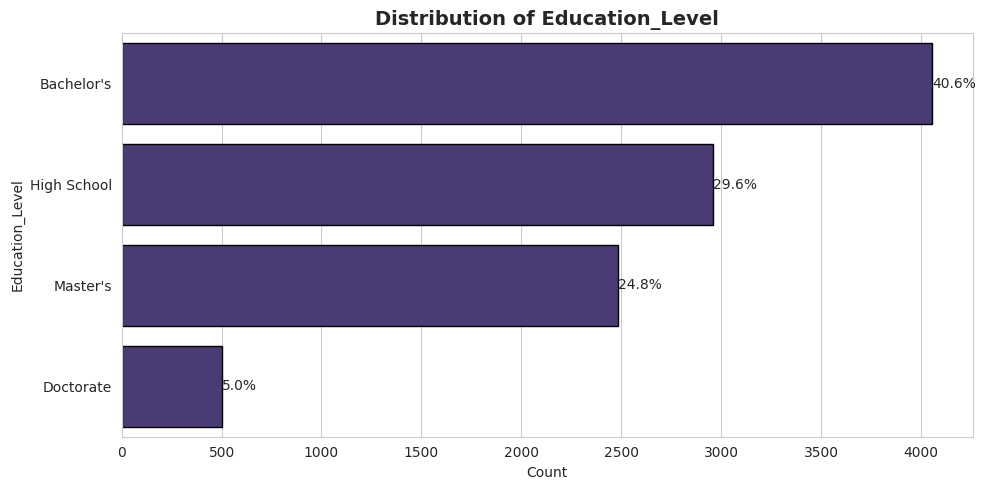

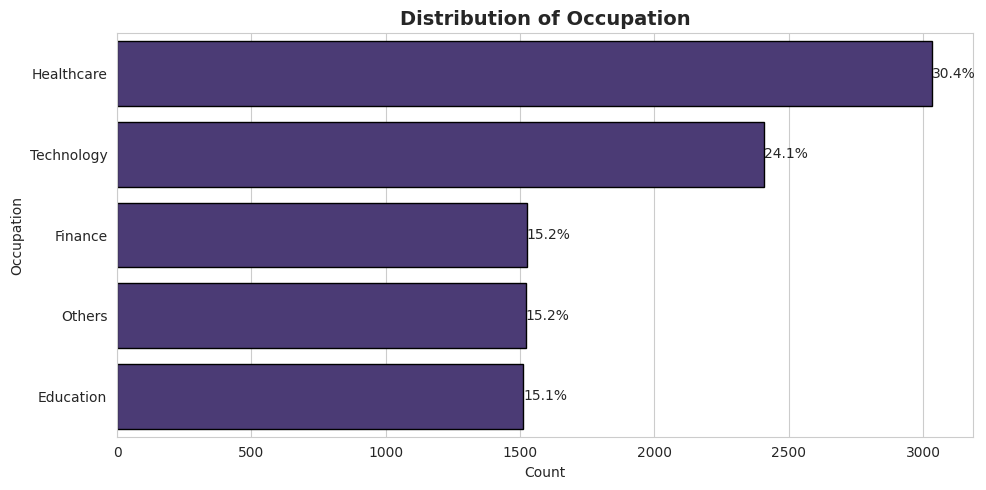

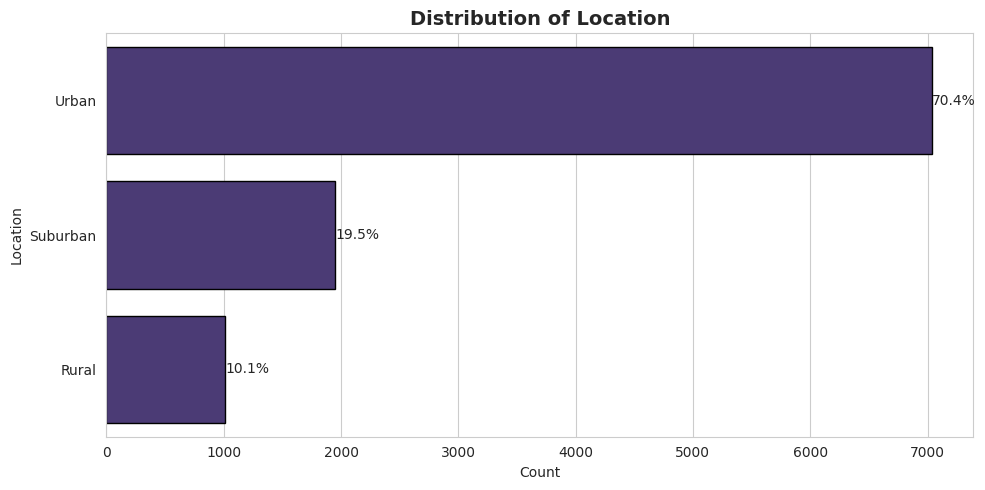

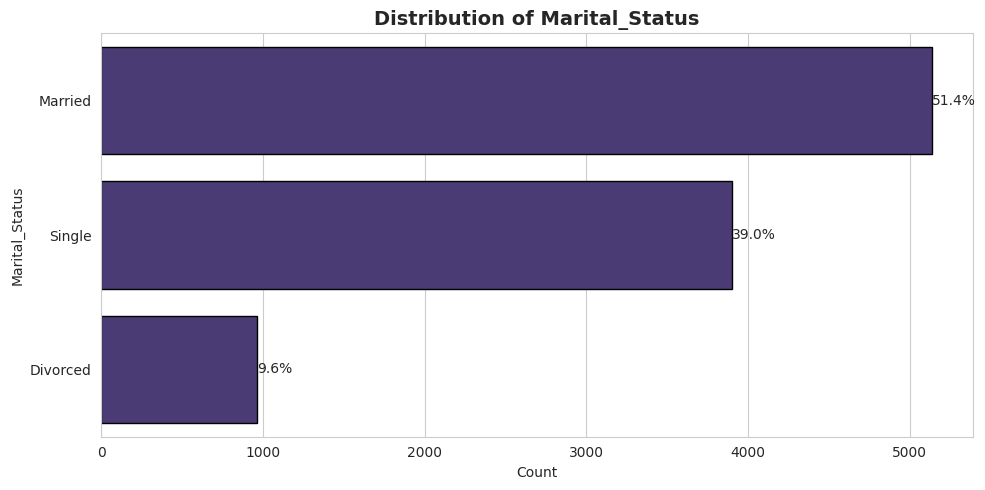

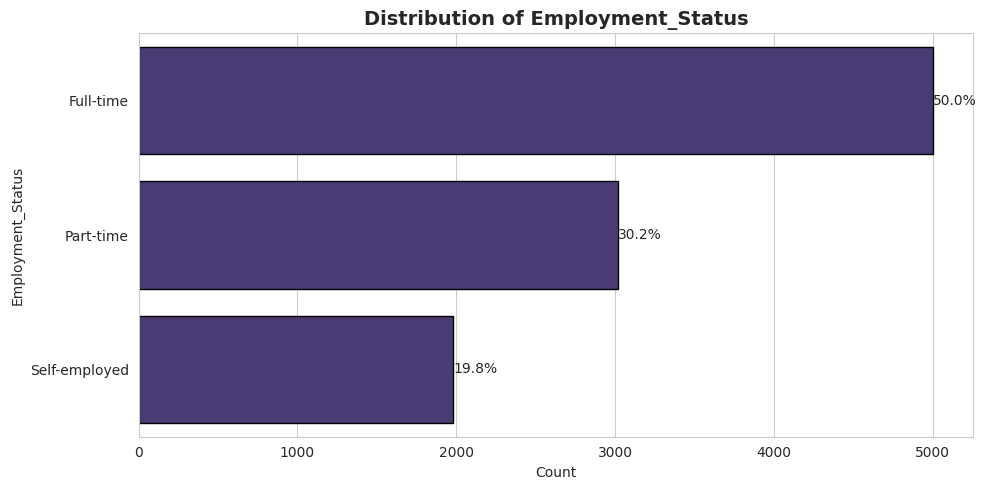

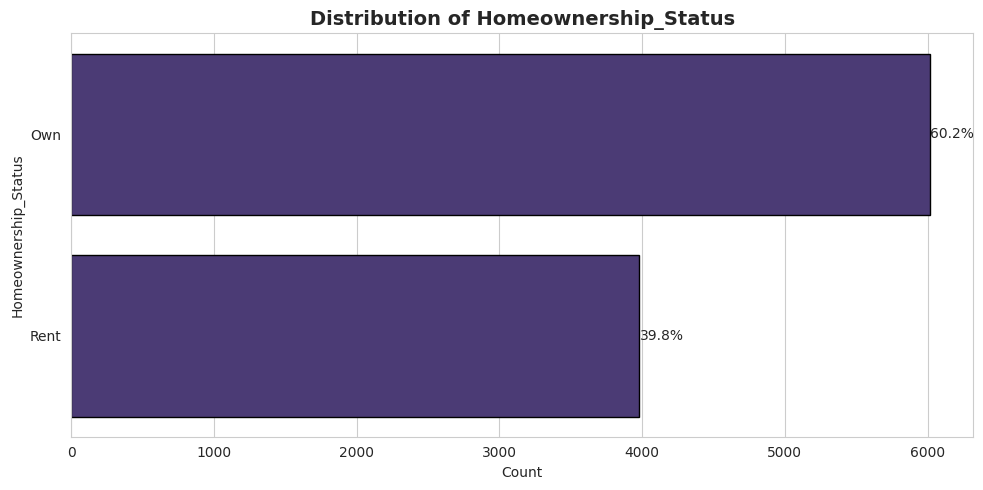

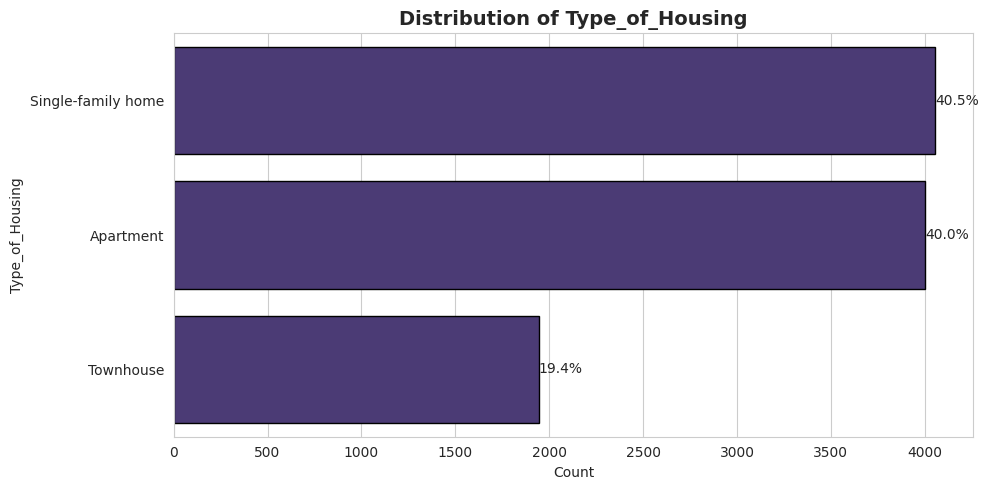

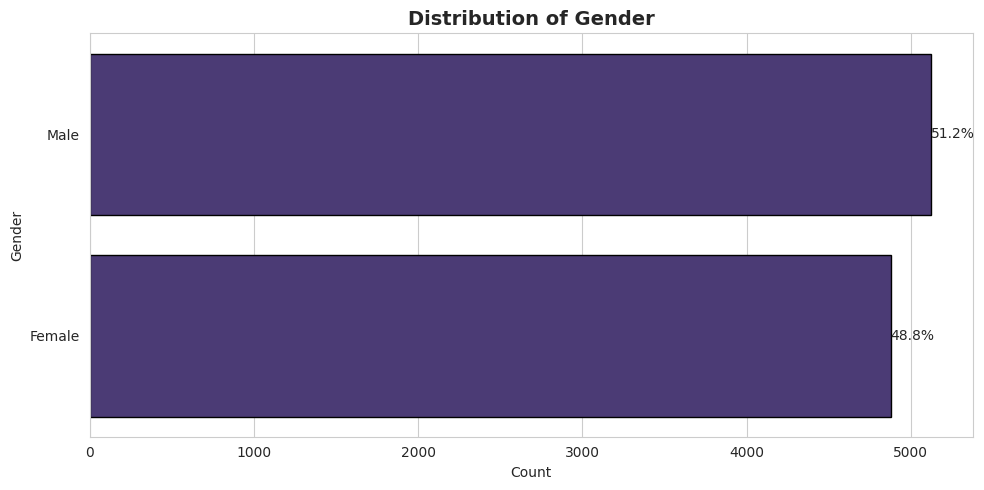

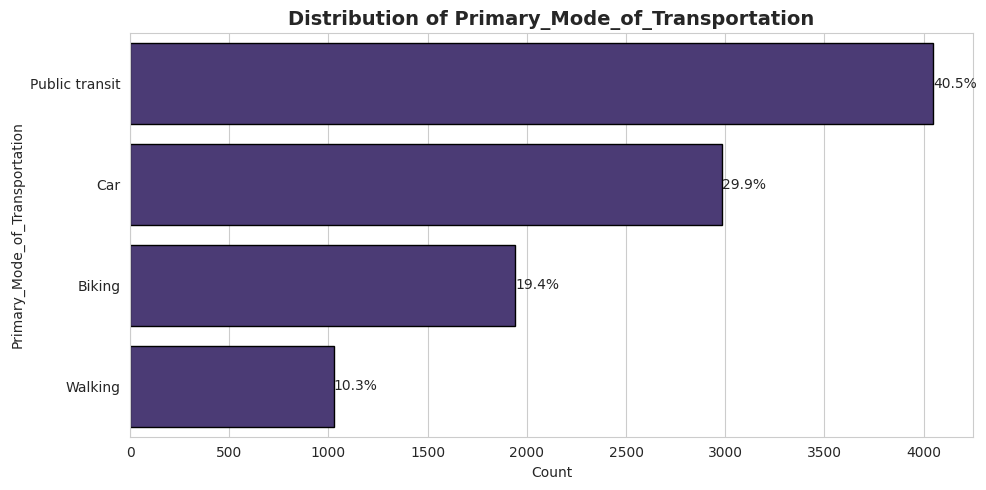

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Global styling
sns.set_style("whitegrid")
sns.set_palette("viridis")

for col in cat_cols:
    
    plt.figure(figsize=(10,5))

    ax = sns.countplot(
        data=income,
        y=col,
        order=income[col].value_counts().index,
        edgecolor="black"
    )

    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.xlabel("Count")
    plt.ylabel(col)

    # Add percentage labels
    total = len(income)
    for p in ax.patches:
        percentage = f'{100 * p.get_width()/total:.1f}%'
        ax.annotate(
            percentage,
            (p.get_width(), p.get_y() + p.get_height()/2),
            ha='left',
            va='center'
        )

    plt.tight_layout()
    plt.show()

🔹 Assumptions

Low-cardinality features can be encoded using One-Hot Encoding without significant dimensionality issues.

Imbalanced features (e.g., Location) may introduce bias in model predictions.

----------------------------------------------------------------------------------------------------------

Observations 
Most numerical features such as Age, Work Experience, Household Size, and Number of Dependents have skewness values close to 0, indicating they are approximately symmetrically distributed.

The Income variable has a very high positive skew (~2.98), indicating a highly right-skewed distribution.

In [29]:
print(income[num_cols].skew())

Age                     0.002184
Number_of_Dependents   -0.016549
Work_Experience        -0.002580
Household_Size          0.003533
Income                  2.983177
dtype: float64


Assumptions

Since most features are normally distributed, they are suitable for regression models without heavy transformation.The high skewness in income suggests the presence of extreme values (outliers), which may negatively impact model performance.

## Visualization

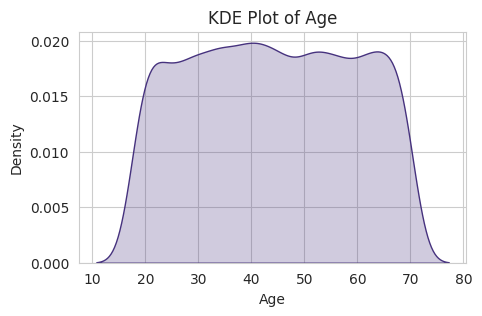

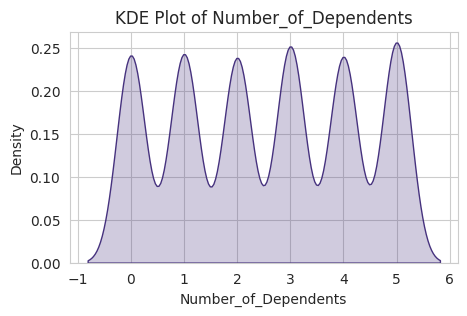

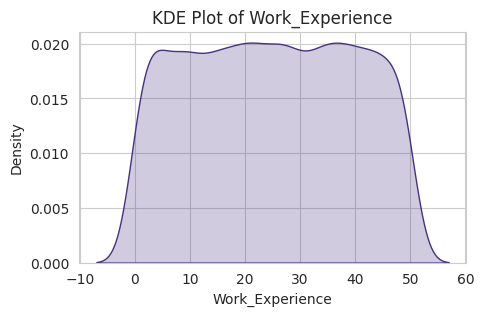

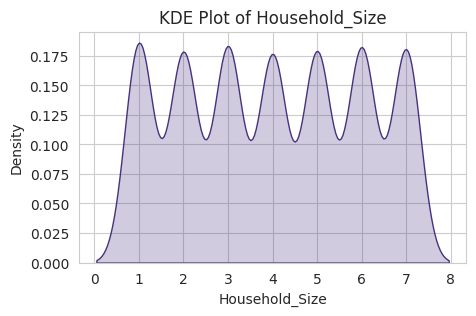

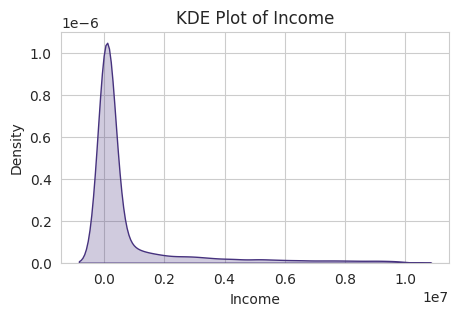

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(income[col], fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.show()

## Bivariate Analysis

# Numerical Values

Observations

Age vs Income
No clear pattern. Points are randomly scattered.
No strong relationship.

Work Experience vs Income
Again, no visible trend.
Experience is not  strong predictor here.

Number of Dependents vs Income
discrete values, but income spread is same across all.
No meaningful impact.

Household Size vs Income
no separation or pattern.
Weak relationship.

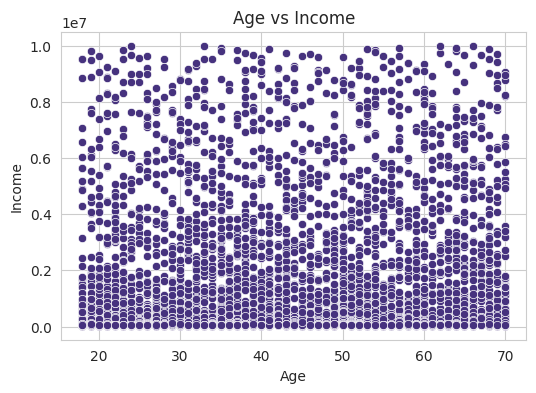

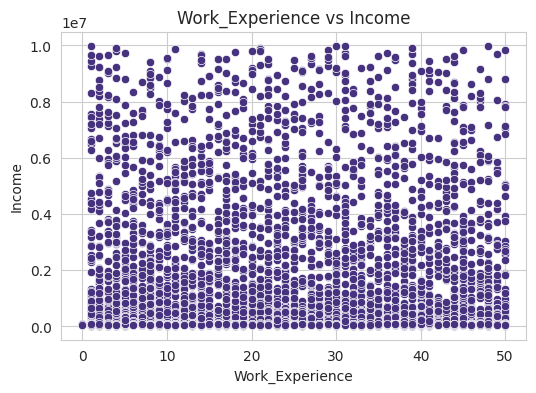

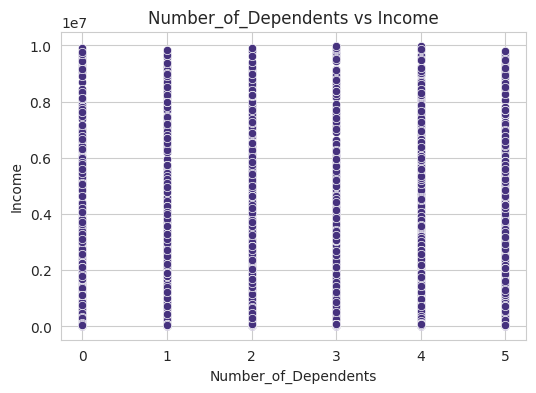

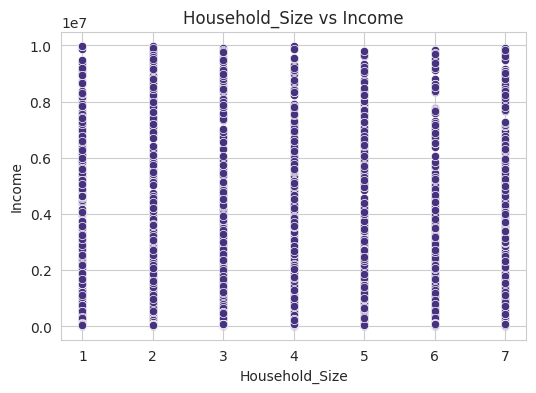

In [35]:
num_cols = ['Age', 'Work_Experience', 'Number_of_Dependents', 'Household_Size']

for col in num_cols:
    plt.figure(figsize=(6,4))
    
    sns.scatterplot(x=col, y='Income', data=income)
    
    plt.title(f'{col} vs Income')
    plt.xlabel(col)
    plt.ylabel('Income')
    
    plt.show()

Assumptions

The numerical features show little to no linear relationship with income, suggesting that they may not be strong predictors for a Linear Regression model.

----------------------------------------------------------------------------------------------------------

# Categorical Values

Observations

The boxplot analysis of categorical features against income indicates that most categories exhibit significant overlap in income distribution, suggesting weak relationships with the target variable.

For Education Level, slight variations in median income are observed; however, the distributions largely overlap, indicating a limited influence on income.

The Occupation feature shows minor differences across categories, but the presence of overlapping distributions suggests low predictive power.

In the case of Location, although certain categories (e.g., Rural) display slightly higher income ranges, the overall distributions are similar, indicating no strong impact.

Marital Status and Gender show almost identical distributions across categories, suggesting that these features have negligible effect on income.

The Employment Status feature shows slight variation, but the differences are not substantial enough to indicate a strong relationship.

The Homeownership Status feature shows some variation between categories (e.g., Rent vs Own), indicating a potential influence on income, though further analysis is required.

Features such as Type of Housing and Primary Mode of Transportation exhibit overlapping distributions, suggesting minimal contribution to income prediction.

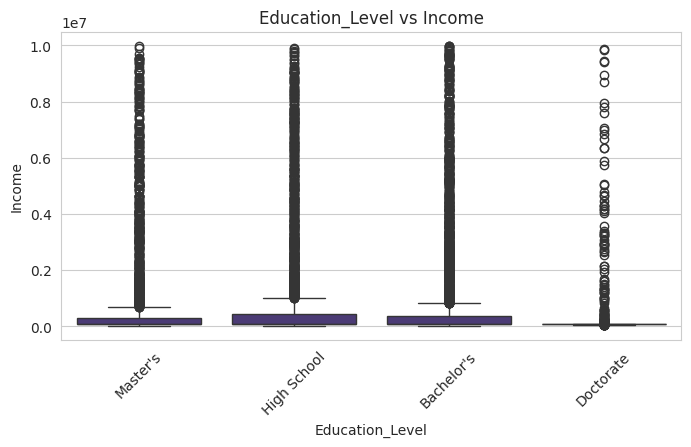

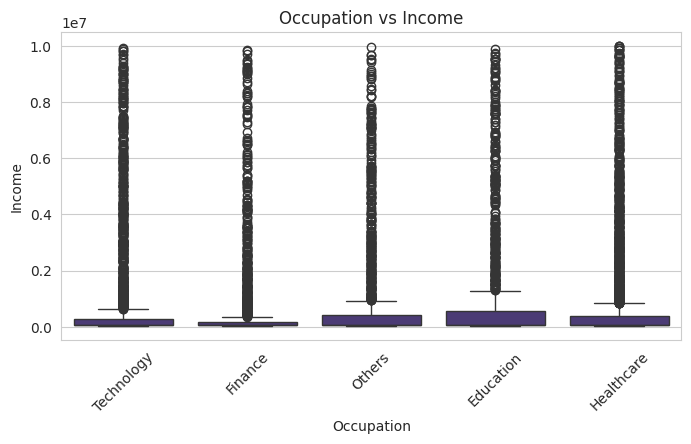

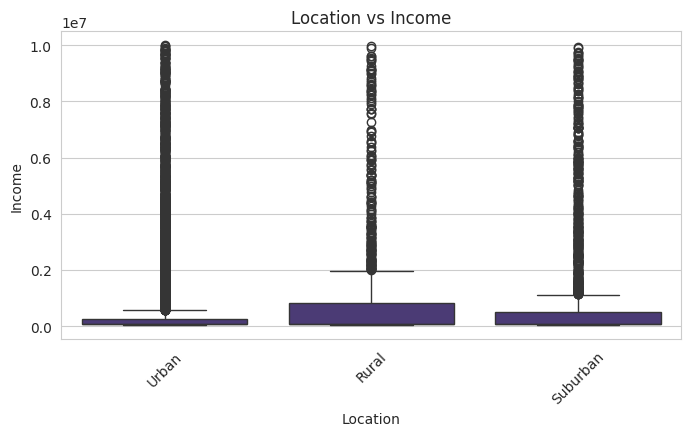

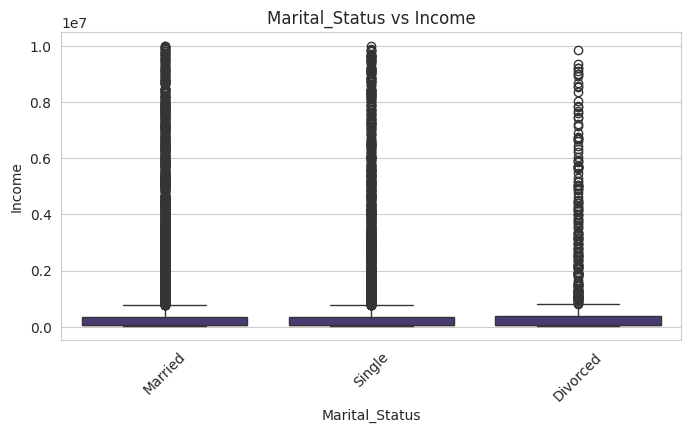

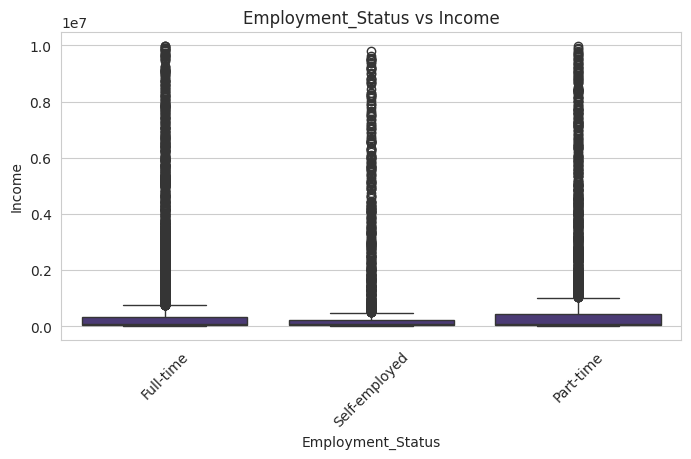

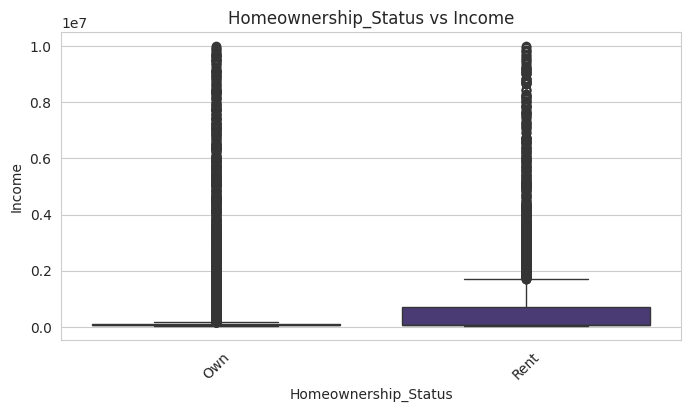

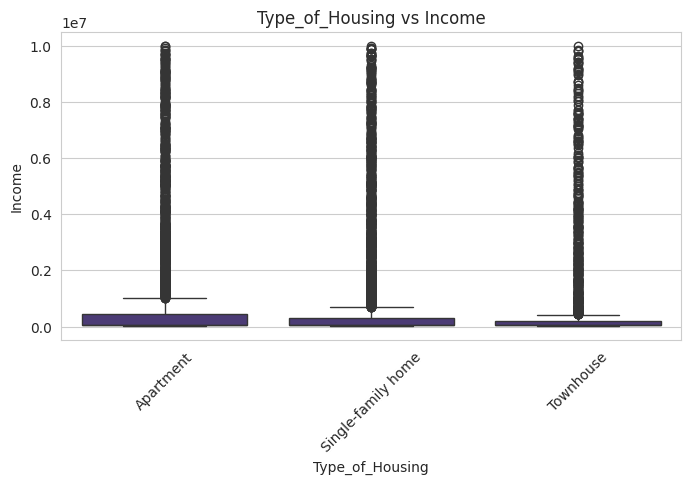

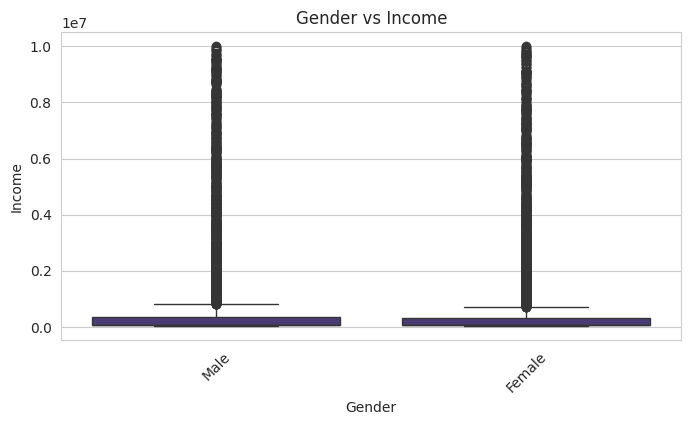

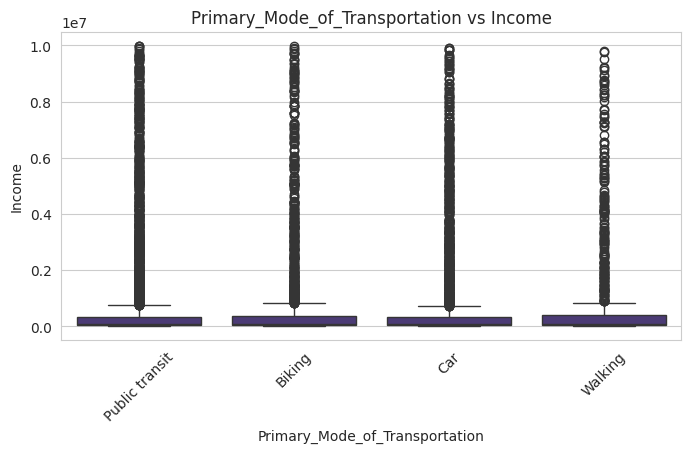

In [39]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=col, y='Income', data=income)
    
    plt.title(f"{col} vs Income")
    plt.xticks(rotation=45)
    
    plt.show()

Assumptions

Most categorical features do not show strong differentiation in income distribution, suggesting they may have limited predictive power in a regression model.
A few features like Homeownership_Status may contain some signal and should be further evaluated.

----------------------------------------------------------------------------------------------------------

Observations

The correlation values between numerical features and the target variable (Income) are very close to zero, indicating no strong linear relationship.

Text(0.5, 1.0, 'Correlation Matrix')

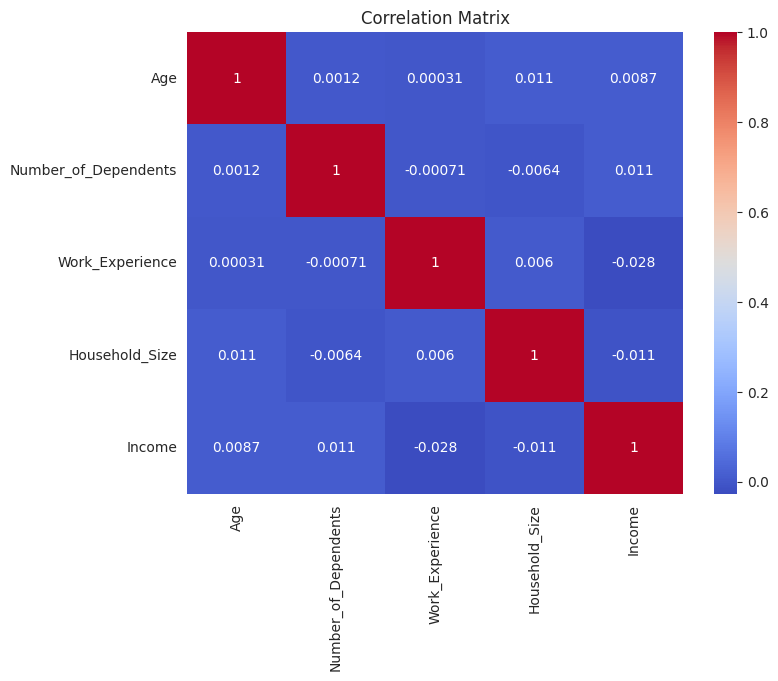

In [40]:
import seaborn as sns  # heatmap is used to detect multivariate

corr = income.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix') 

Assumptions

Since the correlation values are extremely low, it is assumed that the numerical features do not have a significant linear impact on income.

----------------------------------------------------------------------------------------------------------

Based on EDA (boxplots + distributions), categorical features show overlapping income distributions, indicating weak relationships. Therefore, hypothesis testing is unlikely to provide additional useful insights and is skipped.

----------------------------------------------------------------------------------------------------------

# Data Cleaning

 The dataset does not contain missing values or inconsistencies; therefore, extensive data cleaning is not required. Only necessary preprocessing steps such as transformation and encoding will be applied.

----------------------------------------------------------------------------------------------------------

# Feature Engineering 

# Transformation

In [42]:
import numpy as np
income['Income_log'] = np.log1p(income['Income'])

In [44]:
income[['Income', 'Income_log']].head()

,Income,Income_log
0,72510,11.191494
1,75462,11.231398
2,71748,11.180929
3,74520,11.218836
4,640210,13.369553


<Axes: xlabel='Income_log', ylabel='Count'>

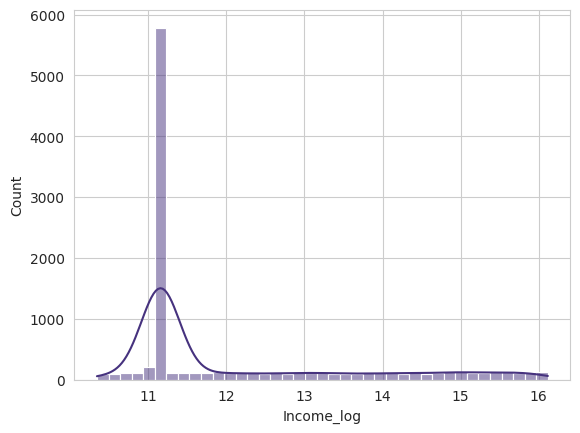

In [45]:
import seaborn as sns
sns.histplot(income['Income_log'], kde=True)

Observations

After applying log transformation, the income distribution becomes less skewed, with values compressed into a narrower range.
The extreme high-income values are reduced in scale, resulting in a more normalized distribution compared to the original data.

----------------------------------------------------------------------------------------------------------

In [46]:
X = income.drop(['Income', 'Income_log'], axis=1)
y = income['Income_log']

Why drop both?

Income : original (leakage risk)
Income_log : target

----------------------------------------------------------------------------------------------------------

# Encoding 

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.astype(int)


,Age,Number_of_Dependents,Work_Experience,Household_Size,Education_Level_Doctorate,Education_Level_High School,Education_Level_Master's,Occupation_Finance,Occupation_Healthcare,Occupation_Others,...,Marital_Status_Single,Employment_Status_Part-time,Employment_Status_Self-employed,Homeownership_Status_Rent,Type_of_Housing_Single-family home,Type_of_Housing_Townhouse,Gender_Male,Primary_Mode_of_Transportation_Car,Primary_Mode_of_Transportation_Public transit,Primary_Mode_of_Transportation_Walking
0,56,5,21,7,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,69,0,4,7,0,1,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
2,46,1,1,7,0,0,0,0,0,0,...,1,0,0,0,1,0,0,1,0,0
3,32,2,32,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,60,3,15,4,0,0,0,1,0,0,...,0,0,1,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,58,0,26,6,0,1,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
9996,23,3,16,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9997,41,3,50,4,1,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
9998,44,0,3,1,0,1,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0


In [51]:
X_encoded.dtypes.head()

Age                          int64
Number_of_Dependents         int64
Work_Experience              int64
Household_Size               int64
Education_Level_Doctorate    int64
dtype: object

# Train-Test Split

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Scaling 

using z-score as it is Preferred for algorithms assuming normal distribution like linear regression

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit ONLY on training data
X_train = scaler.fit_transform(X_train)

# transform test data
X_test = scaler.transform(X_test)

In [57]:
X_train[:5]

array([[-0.00696924,  0.85243833,  0.150006  ,  1.49649598, -0.23062066,
        -0.64823019, -0.57561821, -0.42275765, -0.66323812, -0.41987808,
         1.78012301, -0.48962583,  0.64842466, -1.02609024,  1.25129824,
         1.52889019, -0.5017572 , -0.8107676 ,  1.20862786, -0.48746668,
        -1.02327069, -0.65095382,  1.20083406, -0.33886163],
       [ 0.05885597, -0.30991153, -0.39705561,  1.49649598, -0.23062066,
        -0.64823019, -0.57561821, -0.42275765,  1.5077541 , -0.41987808,
        -0.56175893,  2.04237589, -1.5421992 ,  0.97457316, -0.79916999,
        -0.65406921, -0.5017572 ,  1.23339906,  1.20862786, -0.48746668,
        -1.02327069,  1.53620728, -0.83275453, -0.33886163],
       [ 1.57283593,  1.43361326,  0.0816233 ,  0.49962118,  4.33612502,
        -0.64823019, -0.57561821, -0.42275765, -0.66323812, -0.41987808,
        -0.56175893, -0.48962583, -1.5421992 , -1.02609024,  1.25129824,
         1.52889019, -0.5017572 , -0.8107676 ,  1.20862786, -0.48746668,
  

Observation

After applying StandardScaler, all features are standardized with a mean close to 0 and standard deviation close to 1. This ensures that no feature dominates due to its scale.

----------------------------------------------------------------------------------------------------------

# Model Selection

I have used Linear Regression as a baseline model to evaluate the performance of the dataset before applying more complex algorithms.

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [61]:
y_pred = model.predict(X_test)
y_pred

array([11.72144513, 12.12034367, 11.96961503, ..., 12.33932458,
       11.95758892, 12.23119426], shape=(2000,))

In [62]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.03085669646217415
RMSE: 1.5054455621940037
